# Cluster Quilting: Spectral Clustering on Patchwork Data

Implementation of Algorithm 1 from Zheng, Chang & Allen (2024) — *Cluster Quilting: Spectral Clustering for Patchwork Learning*.

**Steps:**
1. Load patches generated by `generate_quilt.ipynb`
2. Order patches via greedy forward search (Algorithm 2)
3. Patchwise SVD → sequential linear mapping of singular vectors across overlaps
4. k-means on the combined, weighted singular vectors
5. Evaluate clustering against true valence labels

In [33]:
import numpy as np
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import matplotlib.pyplot as plt

## 1. Load Patches

In [34]:
patch_dir = Path('patches')
patch_files = sorted(patch_dir.glob('patch_*.npz'))

patches = []
for f in patch_files:
    p = np.load(f, allow_pickle=True)
    patches.append({
        'data': p['data'],
        'row_idx': p['row_idx'],
        'col_idx': p['col_idx'],
        'valence': p['valence'],
    })

M = len(patches)
N_total = max(p['row_idx'][-1] for p in patches) + 1
P_total = max(p['col_idx'][-1] for p in patches) + 1

print(f'Loaded {M} patches')
print(f'Total samples: {N_total}, Total features: {P_total}')
for i, p in enumerate(patches):
    print(f'  Patch {i}: {p["data"].shape[0]} samples x {p["data"].shape[1]} features, '
          f'rows [{p["row_idx"][0]}–{p["row_idx"][-1]}], '
          f'cols [{p["col_idx"][0]}–{p["col_idx"][-1]}]')

Loaded 3 patches
Total samples: 129603, Total features: 121
  Patch 0: 49141 samples x 56 features, rows [0–49140], cols [0–55]
  Patch 1: 42121 samples x 42 features, rows [49141–91261], cols [19–60]
  Patch 2: 38341 samples x 90 features, rows [91262–129602], cols [31–120]


## 2. Patch Ordering (Algorithm 2 — Greedy Forward Search)

Order patches to maximize overlapping signal at each merge step.  
Score function: overlap size $s(k, I) = |T_k \cap T|$ (number of shared **columns/features**).

**Note:** Our patches have disjoint rows (samples) and overlapping columns (features),
which is transposed relative to the paper's convention. So the merging dimension is
columns (features) instead of rows (samples).

In [35]:
def greedy_patch_ordering(patches):
    """Algorithm 2: Forward search for patch ordering.
    
    Uses column overlap size as the score function: s(k, T) = |T_k ∩ T|.
    """
    M = len(patches)
    col_sets = [set(p['col_idx'].tolist()) for p in patches]
    
    # Find the initial pair (π(1), π(2)) with maximum column overlap
    best_score = -1
    best_pair = (0, 1)
    for i in range(M):
        for j in range(M):
            if i == j:
                continue
            score = len(col_sets[i] & col_sets[j])
            if score > best_score:
                best_score = score
                best_pair = (i, j)
    
    ordering = [best_pair[0], best_pair[1]]
    used = set(ordering)
    accumulated_cols = col_sets[best_pair[0]] | col_sets[best_pair[1]]
    
    # Greedily add remaining patches
    for _ in range(2, M):
        best_next = -1
        best_s = -1
        for j in range(M):
            if j in used:
                continue
            s = len(col_sets[j] & accumulated_cols)
            if s > best_s:
                best_s = s
                best_next = j
        ordering.append(best_next)
        used.add(best_next)
        accumulated_cols |= col_sets[best_next]
    
    return ordering

ordering = greedy_patch_ordering(patches)
print(f'Patch ordering: {ordering}')

# Show overlaps in the chosen order
accumulated = set(patches[ordering[0]]['col_idx'].tolist())
for k in range(1, M):
    idx = ordering[k]
    current_cols = set(patches[idx]['col_idx'].tolist())
    overlap = len(current_cols & accumulated)
    print(f'  Step {k}: merge patch {idx}, column overlap = {overlap} features')
    accumulated |= current_cols

Patch ordering: [0, 1, 2]
  Step 1: merge patch 1, column overlap = 37 features
  Step 2: merge patch 2, column overlap = 30 features


## 3. Cluster Quilting (Algorithm 1 — adapted for column overlap)

Our patches have **disjoint rows** and **overlapping columns**, which is transposed
relative to the paper's convention (disjoint features, overlapping samples).

Adaptation: merge patches via their overlapping **feature** (column) dimension.
- For each patch $X_m = U_m \Sigma_m V_m^\top$ (samples × features):
  - $V_m$ (feature singular vectors) are aligned across overlapping columns
  - $U_m \Sigma_m$ (sample loadings) are accumulated into the sample space
- Post-process and run k-means on the sample representation

In [36]:
def cluster_quilting(patches, ordering, r, K):
    """Algorithm 1 (adapted for column overlap): Cluster Quilting.
    
    Paper convention: X ∈ R^{p×n}, disjoint features T_m, overlapping samples I_m.
    Our convention:   X ∈ R^{n×p}, disjoint samples (rows), overlapping features (cols).
    
    We transpose the merge logic: align feature-space singular vectors (V_m)
    across overlapping columns, and accumulate sample-space vectors (U_m * S_m).
    
    Parameters
    ----------
    patches : list of dict
        Each dict has 'data', 'row_idx', 'col_idx'.
    ordering : list of int
        Patch indices in merge order.
    r : int
        Rank for truncated SVD.
    K : int
        Number of clusters.
    
    Returns
    -------
    labels : ndarray of shape (n_total,)
        Cluster assignments.
    H_tilde : ndarray of shape (n_total, r)
        Combined sample-space vectors.
    V_tilde : ndarray of shape (p_total, r)
        Combined feature-space vectors.
    features_for_kmeans : ndarray of shape (n_total, r)
        Weighted singular vectors used for k-means.
    """
    n_total = max(p['row_idx'][-1] for p in patches) + 1
    p_total = max(p['col_idx'][-1] for p in patches) + 1
    
    # V_tilde: feature-space (p_total × r) — merged via overlapping columns
    # H_tilde: sample-space  (n_total × r) — accumulated per patch
    V_tilde = np.zeros((p_total, r))
    H_tilde = np.zeros((n_total, r))
    
    covered_cols = set()
    
    # --- First patch ---
    m0 = ordering[0]
    X_m = patches[m0]['data']  # (n_m × p_m)
    U, S, Vt = np.linalg.svd(X_m, full_matrices=False)
    U_r = U[:, :r]        # (n_m, r)
    S_r = S[:r]            # (r,)
    V_r = Vt[:r, :].T     # (p_m, r)
    
    row_idx = patches[m0]['row_idx']
    col_idx = patches[m0]['col_idx']
    
    V_tilde[col_idx, :] = V_r
    H_tilde[row_idx, :] = U_r * S_r[np.newaxis, :]
    covered_cols.update(col_idx.tolist())
    
    # --- Subsequent patches ---
    for step in range(1, len(ordering)):
        m = ordering[step]
        X_m = patches[m]['data']
        row_idx = patches[m]['row_idx']
        col_idx = patches[m]['col_idx']
        
        # SVD of current patch
        U, S, Vt = np.linalg.svd(X_m, full_matrices=False)
        U_r = U[:, :r]
        S_r = S[:r]
        V_r = Vt[:r, :].T  # (p_m, r)
        
        # Find overlapping columns
        current_cols = set(col_idx.tolist())
        overlap_global = sorted(current_cols & covered_cols)
        
        if len(overlap_global) < r:
            print(f'  Warning: patch {m} has only {len(overlap_global)} overlapping features (need >= {r})')
            # Still accumulate what we can without alignment
            V_tilde[col_idx, :] = V_r
            H_tilde[row_idx, :] = U_r * S_r[np.newaxis, :]
            covered_cols.update(col_idx.tolist())
            continue
        
        # Map global column indices to local indices within this patch
        col_idx_list = col_idx.tolist()
        global_to_local = {g: l for l, g in enumerate(col_idx_list)}
        local_overlap = [global_to_local[g] for g in overlap_global]
        
        # V_m at overlap columns (local)
        V_m_overlap = V_r[local_overlap, :]  # (|overlap|, r)
        
        # V_tilde at overlap columns (global)
        V_tilde_overlap = V_tilde[overlap_global, :]  # (|overlap|, r)
        
        # Least-squares: V_m_overlap @ G_m ≈ V_tilde_overlap
        G_m, _, _, _ = np.linalg.lstsq(V_m_overlap, V_tilde_overlap, rcond=None)
        
        # Assign new (non-overlap) columns
        new_global = sorted(current_cols - covered_cols)
        if new_global:
            new_local = [global_to_local[g] for g in new_global]
            V_tilde[new_global, :] = V_r[new_local, :] @ G_m
        
        # H_m = U_r * S_r, transform: H_tilde[rows] = H_m @ (G_m^T)^{-1}
        H_m = U_r * S_r[np.newaxis, :]
        G_m_inv_T = np.linalg.solve(G_m.T, np.eye(r))
        H_tilde[row_idx, :] = H_m @ G_m_inv_T
        
        covered_cols.update(col_idx.tolist())
    
    # --- Post-processing ---
    # H_tilde @ V_tilde^T ≈ X (n × p). SVD via small r×r factorization.
    Q_H, R_H = np.linalg.qr(H_tilde)
    Q_V, R_V = np.linalg.qr(V_tilde)
    U_small, S_final, Vt_small = np.linalg.svd(R_H @ R_V.T, full_matrices=False)
    
    # U_hat (sample space) = Q_H @ U_small, Λ = diag(S_final)
    U_hat = Q_H @ U_small  # (n, r)
    Lambda_hat = np.diag(S_final)
    
    # k-means on Λ U_hat^T columns → each sample's feature = U_hat @ Λ row
    features_for_kmeans = U_hat @ Lambda_hat  # (n, r)
    
    km = KMeans(n_clusters=K, n_init=50, random_state=42)
    labels = km.fit_predict(features_for_kmeans)
    
    return labels, H_tilde, V_tilde, features_for_kmeans

## 4. Run Cluster Quilting

In [37]:
# Reconstruct global valence labels from patches
valence_global = np.empty(N_total, dtype=object)
for p in patches:
    valence_global[p['row_idx']] = p['valence']

categories = np.unique(valence_global)
K = 3
r = K - 1  # rank = K-1 (standard choice for K clusters)

print(f'Number of clusters K = {K}')
print(f'Rank r = {r}')
print(f'Categories: {categories}')

labels, V_tilde, H_tilde, km_features = cluster_quilting(patches, ordering, r=r, K=K)

Number of clusters K = 3
Rank r = 2
Categories: ['Air_US' 'ITI' 'Sucrose_US']


## 5. Evaluation

In [38]:
ari = adjusted_rand_score(valence_global, labels)
nmi = normalized_mutual_info_score(valence_global, labels)

print(f'Adjusted Rand Index:          {ari:.4f}')
print(f'Normalized Mutual Information: {nmi:.4f}')

# Confusion-style table: cluster vs valence
print(f'\nCluster composition:')
print(f'{"":>10}', end='')
for cat in categories:
    print(f'{cat:>14}', end='')
print()
for k in range(K):
    mask = labels == k
    print(f'Cluster {k}:', end='')
    for cat in categories:
        count = np.sum((valence_global == cat) & mask)
        print(f'{count:>14}', end='')
    print(f'  (total: {mask.sum()})')

Adjusted Rand Index:          0.1607
Normalized Mutual Information: 0.1397

Cluster composition:
                  Air_US           ITI    Sucrose_US
Cluster 0:          4488         36787          8462  (total: 49737)
Cluster 1:          4411          4572         24489  (total: 33472)
Cluster 2:         10369         23783         12242  (total: 46394)


## 6. Visualization

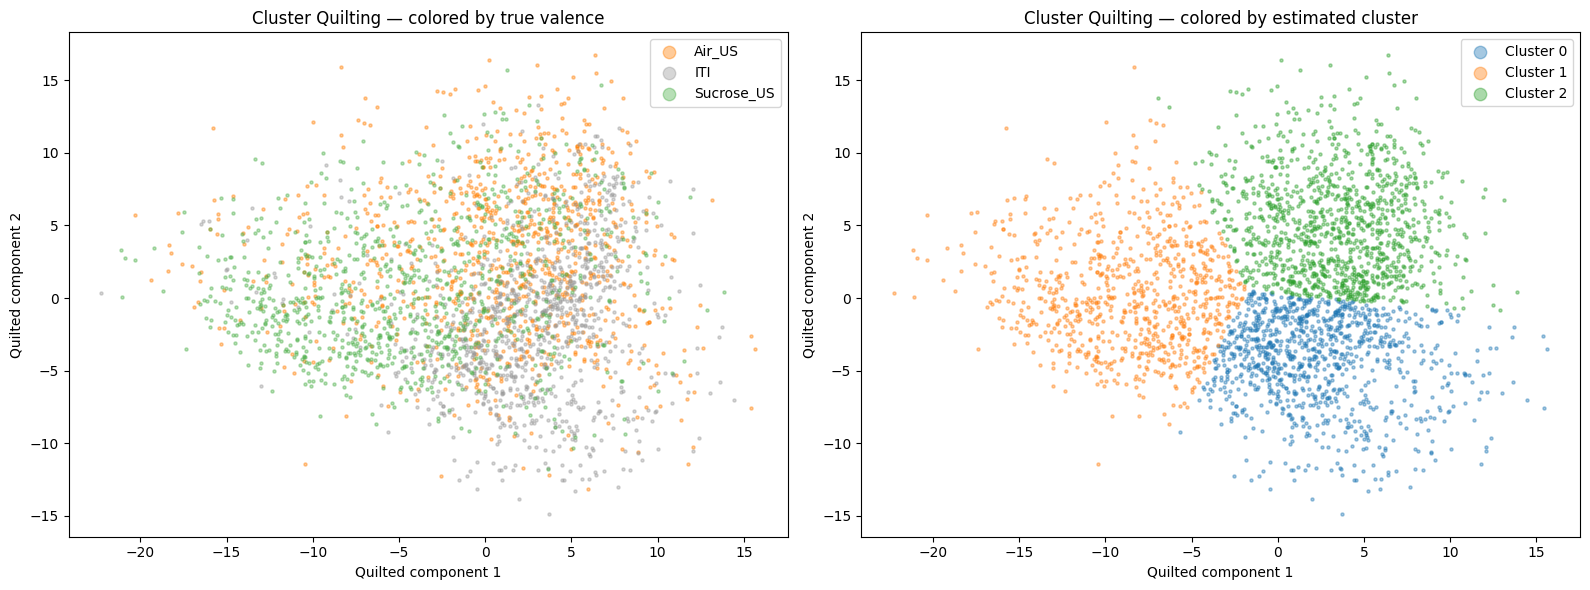


ARI = 0.1607, NMI = 0.1397


In [39]:
# Subsample for plotting
rng = np.random.default_rng(42)
n_per_cat = 1000
sample_idx = []
for cat in categories:
    cat_idx = np.where(valence_global == cat)[0]
    chosen = rng.choice(cat_idx, size=min(n_per_cat, len(cat_idx)), replace=False)
    sample_idx.append(chosen)
sample_idx = np.concatenate(sample_idx)

feat_sub = km_features[sample_idx]
val_sub = valence_global[sample_idx]
lab_sub = labels[sample_idx]

colors = {'Air_CS': '#e41a1c', 'Air_US': '#ff7f00',
          'ITI': '#999999',
          'Sucrose_CS': '#377eb8', 'Sucrose_US': '#4daf4a'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: colored by true valence
for cat in categories:
    mask = val_sub == cat
    axes[0].scatter(feat_sub[mask, 0], feat_sub[mask, 1],
                    s=5, alpha=0.4, label=cat, color=colors.get(cat, '#000'))
axes[0].set_xlabel('Quilted component 1')
axes[0].set_ylabel('Quilted component 2')
axes[0].set_title('Cluster Quilting — colored by true valence')
axes[0].legend(markerscale=4)

# Right: colored by k-means cluster
for k in range(K):
    mask = lab_sub == k
    axes[1].scatter(feat_sub[mask, 0], feat_sub[mask, 1],
                    s=5, alpha=0.4, label=f'Cluster {k}')
axes[1].set_xlabel('Quilted component 1')
axes[1].set_ylabel('Quilted component 2')
axes[1].set_title('Cluster Quilting — colored by estimated cluster')
axes[1].legend(markerscale=4)

plt.tight_layout()
plt.savefig('cluster_quilting_results.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nARI = {ari:.4f}, NMI = {nmi:.4f}')

## 7. Sensitivity: Varying Rank $r$

In [40]:
print(f'{"r":>3}  {"ARI":>8}  {"NMI":>8}')
print('-' * 23)
for r_test in range(2, K + 3):
    lab_r, _, _, _ = cluster_quilting(patches, ordering, r=r_test, K=K)
    ari_r = adjusted_rand_score(valence_global, lab_r)
    nmi_r = normalized_mutual_info_score(valence_global, lab_r)
    marker = ' <--' if r_test == r else ''
    print(f'{r_test:>3}  {ari_r:>8.4f}  {nmi_r:>8.4f}{marker}')

  r       ARI       NMI
-----------------------
  2    0.1607    0.1397 <--
  3    0.0107    0.0154
  4    0.1486    0.1116
  5    0.0226    0.0141
